In [296]:
from casadi import *
import numpy as np

In [297]:
model_name = 'UR5';

# States
q1_1 = SX.sym('q1_1');q1_2 = SX.sym('q1_2');q1_3 = SX.sym('q1_3');
q1_4 = SX.sym('q1_4');q1_5 = SX.sym('q1_5');q1_6 = SX.sym('q1_6');

# Controls
u1_1 = SX.sym('u1_1');u1_2 = SX.sym('u1_2');u1_3 = SX.sym('u1_3');
u1_4 = SX.sym('u1_4');u1_5 = SX.sym('u1_5');u1_6 = SX.sym('u1_6');

# acceleration controls
a1_1 = SX.sym('a1_1');a1_2 = SX.sym('a1_2');a1_3 = SX.sym('a1_3');
a1_4 = SX.sym('a1_4');a1_5 = SX.sym('a1_5');a1_6 = SX.sym('a1_6');

# L1 slack variables (6 for position error + 6 for velocity error)
s1_1 = SX.sym('s1_1'); s1_2 = SX.sym('s1_2'); s1_3 = SX.sym('s1_3')
s1_4 = SX.sym('s1_4'); s1_5 = SX.sym('s1_5'); s1_6 = SX.sym('s1_6')
s1_7 = SX.sym('s1_7'); s1_8 = SX.sym('s1_8'); s1_9 = SX.sym('s1_9')
s1_10 = SX.sym('s1_10'); s1_11 = SX.sym('s1_11'); s1_12 = SX.sym('s1_12')

sym_x_short = vertcat(q1_1, q1_2, q1_3, q1_4, q1_5, q1_6);
sym_u_short = vertcat(u1_1, u1_2, u1_3, u1_4, u1_5, u1_6);
sym_a_short = vertcat(a1_1, a1_2, a1_3, a1_4, a1_5, a1_6);

sym_x = vertcat(q1_1, q1_2, q1_3, q1_4, q1_5, q1_6,
                u1_1, u1_2, u1_3, u1_4, u1_5, u1_6)
sym_u = vertcat(a1_1, a1_2, a1_3, a1_4, a1_5, a1_6,
                s1_1, s1_2, s1_3, s1_4, s1_5, s1_6,
                s1_7, s1_8, s1_9, s1_10, s1_11, s1_12)

p = SX.sym('p', 7)
w = p[0]
theta_f = p[1:7]

Ts = 0.25

q_next = sym_x_short + Ts * sym_u_short + (Ts*Ts)/2 * sym_a_short
u_next = sym_u_short + Ts * sym_a_short

x_next = vertcat(q_next, u_next)
# expr_f_expl = vcat([sym_u_short,sym_a_short]) # simple integrator


In [298]:
x_next

SX(@1=0.25, @2=0.03125, [((q1_1+(@1*u1_1))+(@2*a1_1)), ((q1_2+(@1*u1_2))+(@2*a1_2)), ((q1_3+(@1*u1_3))+(@2*a1_3)), ((q1_4+(@1*u1_4))+(@2*a1_4)), ((q1_5+(@1*u1_5))+(@2*a1_5)), ((q1_6+(@1*u1_6))+(@2*a1_6)), (u1_1+(@1*a1_1)), (u1_2+(@1*a1_2)), (u1_3+(@1*a1_3)), (u1_4+(@1*a1_4)), (u1_5+(@1*a1_5)), (u1_6+(@1*a1_6))])

In [299]:
## Forward kinematics
# from auto_transform
# 1 joint
# base_link_||_shoulder_link

TB1=vertcat(
horzcat(cos(q1_1), -sin(q1_1), 0,                                   0),
horzcat(sin(q1_1),  cos(q1_1), 0,                                   0),
horzcat(      0,        0, 1, 0.089159000000000002139621813057602),
horzcat(      0,        0, 0,                                   1)
);


# 2 joint
# shoulder_link_||_upper_arm_link
T12=vertcat(
horzcat(-sin(q1_2), 0,  cos(q1_2),       0),
horzcat(       0, 1,        0, 0.13585),
horzcat(-cos(q1_2), 0, -sin(q1_2),       0),
horzcat(       0, 0,        0,       1),
 );


# 3 joint
# upper_arm_link_||_forearm_link
T23=vertcat(
horzcat( cos(q1_3), 0, sin(q1_3),       0),
horzcat(       0, 1,       0, -0.1197),
horzcat(-sin(q1_3), 0, cos(q1_3),   0.425),
horzcat(       0, 0,       0,       1)
       );

# 4 joint
# forearm_link_||_wrist_1_link
T34=vertcat(
horzcat(-sin(q1_4), 0,  cos(q1_4),       0),
horzcat(       0, 1,        0,       0),
horzcat(-cos(q1_4), 0, -sin(q1_4), 0.39225),
horzcat(       0, 0,        0,       1)
       );

# 5 joint
# wrist_1_link_||_wrist_2_link
T45=vertcat(
horzcat(cos(q1_5), -sin(q1_5), 0,     0),
horzcat(sin(q1_5),  cos(q1_5), 0, 0.093),
horzcat(      0,        0, 1,     0),
horzcat(      0,        0, 0,     1)
       );

# 6 joint
# wrist_2_link_||_wrist_3_link
T56=vertcat(
horzcat( cos(q1_6), 0, sin(q1_6),       0),
horzcat(       0, 1,       0,       0),
horzcat(-sin(q1_6), 0, cos(q1_6), 0.09465),
horzcat(       0, 0,       0,       1)
       );

T6tool =  SX([
[    0.0000,   -1.0000,         0,         0],
[    1.0000,    0.0000,         0,    0.0823],
[         0,         0,    1.0000,         0],
[         0,         0,         0,    1.0000]
]);

TP1_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0679],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);

TP2_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,           0],
[         0,         0,    1.0000,      0.2125],
[         0,         0,         0,      1.0000]
]);

TP3_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0679],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);

TP4_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,           0],
[         0,         0,    1.0000,      0.1294],
[         0,         0,         0,      1.0000]
]);

TP5_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,           0],
[         0,         0,    1.0000,      0.2589],
[         0,         0,         0,      1.0000]
]);

TP6_shift = SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0465],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);

TP7_shift = SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0411],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);
# here we need to find points from j2 to end-effector
T1 = mtimes(TB1,T12);
T2 = mtimes(T1,T23);
T3 = mtimes(T2,T34); 
T4 = mtimes(T3,T45); 
T5 = mtimes(T4,T56); 
T6 = mtimes(T5,T6tool);
Tp1 = mtimes(TB1,TP1_shift);
Tp2 = mtimes(T1,TP2_shift);
Tp3 = mtimes(T2,TP3_shift);
Tp4 = mtimes(T2,TP4_shift);
Tp5 = mtimes(T2,TP5_shift);
Tp6 = mtimes(T3,TP6_shift);
Tp7 = mtimes(T5,TP7_shift);


#T_calibration = T6_1*T7end*Tend2tool;
F_cart_1 = horzcat(Tp1[0:3,3], Tp2[0:3,3], Tp3[0:3,3], Tp4[0:3,3], Tp5[0:3,3], Tp6[0:3,3], Tp7[0:3,3]);

## Velocities
Jv1_1 = jtimes(Tp1[0:3,3], sym_x_short.T, sym_u_short.T);
Jv2_1 = jtimes(Tp2[0:3,3], sym_x_short.T, sym_u_short.T);
Jv3_1 = jtimes(Tp3[0:3,3], sym_x_short.T, sym_u_short.T);
Jv4_1 = jtimes(Tp4[0:3,3], sym_x_short.T, sym_u_short.T);
Jv5_1 = jtimes(Tp5[0:3,3], sym_x_short.T, sym_u_short.T);
Jv6_1 = jtimes(Tp6[0:3,3], sym_x_short.T, sym_u_short.T);
Jv7_1 = jtimes(Tp7[0:3,3], sym_x_short.T, sym_u_short.T);


vels_array_1 = vertcat(Jv1_1[0]**2+Jv1_1[1]**2+Jv1_1[2]**2,
              Jv2_1[0]**2+Jv2_1[1]**2+Jv2_1[2]**2,
              Jv3_1[0]**2+Jv3_1[1]**2+Jv3_1[2]**2,
              Jv4_1[0]**2+Jv4_1[1]**2+Jv4_1[2]**2,
              Jv5_1[0]**2+Jv5_1[1]**2+Jv5_1[2]**2,
              Jv6_1[0]**2+Jv6_1[1]**2+Jv6_1[2]**2,
              Jv7_1[0]**2+Jv7_1[1]**2+Jv7_1[2]**2);

F_cart_vels_1 = vels_array_1;

In [300]:
## Constraints

Rt1 = 0.15;
Rt2 = 0.15;
Rt3 = 0.15;
Rt4 = 0.08;
Rt5 = 0.08;
Rt6 = 0.12;
Rt7 = 0.10;
Rt = [0.15, 0.15, 0.15, 0.08, 0.08, 0.12, 0.10]; # Spheres around robot

##
h_expression_array = [];
h_lower_bounds = [];
h_upper_bounds = [];
##

calc_pose_robot_1 = F_cart_1;
calc_vels_robot_1 = F_cart_vels_1;


In [301]:
# avoid self collision
h_expression_array = vertcat(h_expression_array, 
    (Rt1**2 + Rt7**2 - 
     ((calc_pose_robot_1[0,6]-calc_pose_robot_1[0,0])**2 +
      (calc_pose_robot_1[1,6]-calc_pose_robot_1[1,0])**2 + 
      (calc_pose_robot_1[2,6]-calc_pose_robot_1[2,0])**2)));
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);

In [302]:
# Full state error: position error + velocity error (desired velocity = 0)
theta_err = sym_x - vertcat(theta_f, SX.zeros(6))
s = sym_u[6:18]

h_l1 = vertcat(
    theta_err - s,      # x_i - x_f_i <= s_i
   -theta_err - s,      # -(x_i - x_f_i) <= s_i
   -s                  # s_i >= 0  -> -s_i <= 0
)

h_expression_array = vertcat(h_expression_array, h_l1)
h_lower_bounds = vertcat(h_lower_bounds, -1e9 * np.ones(h_l1.size()[0]))
h_upper_bounds = vertcat(h_upper_bounds, np.zeros(h_l1.size()[0]))

In [303]:
theta_err

SX([(q1_1-p_1), (q1_2-p_2), (q1_3-p_3), (q1_4-p_4), (q1_5-p_5), (q1_6-p_6), u1_1, u1_2, u1_3, u1_4, u1_5, u1_6])

In [304]:
import matplotlib.pyplot as plt

from acados_template import AcadosOcp, AcadosOcpSolver, AcadosModel, AcadosSimSolver, AcadosSim
from scipy.linalg import block_diag

In [305]:
model = AcadosModel()

# model.f_expl_expr = expr_f_expl # if integrator_type = 'ERK'
model.disc_dyn_expr = x_next
model.x = sym_x
model.u = sym_u
model.p = p
model.name = model_name

In [306]:
# create ocp object to formulate the OCP

x0 = np.array([0.0, -2.3, -1.1, -1.2, -1.2, 0.5])
xf = np.array([3.0, -1.6, -1.7, -1.7, -1.7, 1.0])

use_cython = True

# N - maximum number of bangs
N = 10 # Number of steps
Tf = 2.5
nx = model.x.size()[0]
nu = model.u.size()[0]



In [307]:
ocp = AcadosOcp()
ocp.model = model

# set dimensions
ocp.dims.N = N
ocp.dims.np = 7
ocp.parameter_values = np.concatenate(([1.0], xf))

# set cost
ocp.cost.cost_type = 'EXTERNAL'
ocp.cost.cost_type_e = 'EXTERNAL'

s = sym_u[6:18]
ocp.model.cost_expr_ext_cost = w * sum1(s)
ocp.model.cost_expr_ext_cost_e = 0 # 1000 * sumsqr(sym_x - vertcat(theta_f, SX.zeros(6)))

ocp.constraints.idxbu = np.arange(18)
ocp.constraints.lbu = np.array([-2.0,-2.0,-2.0,-2.0,-2.0,-2.0] + [0.0]*12)  # -4.4
ocp.constraints.ubu = np.array([ 2.0, 2.0, 2.0, 2.0, 2.0, 2.0] + [1e6]*12)  # 4.4

ocp.constraints.idxbx = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
ocp.constraints.lbx =  np.array([-2*pi,-2*pi,-2*pi,-2*pi,-2*pi,-2*pi, -10, -10, -10, -10, -10, -10]); # -1.2
ocp.constraints.ubx = np.array([2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 10, 10, 10, 10, 10, 10]);  # 1.2

#ocp.constraints.x0 = np.array([0.0, -2.3, -1.1, -1.2, -1.2, 0.5, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

ocp.constraints.idxbx_0 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
ocp.constraints.lbx_0 = np.concatenate([x0, np.zeros(6)]) #, np.zeros(6)
ocp.constraints.ubx_0 = np.concatenate([x0, np.zeros(6)])

ocp.constraints.idxbx_e = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
ocp.constraints.lbx_e = np.concatenate([xf, np.zeros(6)])
ocp.constraints.ubx_e = np.concatenate([xf, np.zeros(6)])

ocp.constraints.constr_type = 'BGH'

# set prediction horizon
ocp.solver_options.tf = Tf


In [308]:
# set options
# Keep the L1 reformulation with slacks, but use cheaper solver settings.
# Since theta_f enters through parameters, the affine L1 inequalities stay in con_h_expr here.
ocp.solver_options.qp_solver = 'PARTIAL_CONDENSING_HPIPM' #'FULL_CONDENSING_HPIPM' #'PARTIAL_CONDENSING_HPIPM' # FULL_CONDENSING_QPOASES
ocp.solver_options.qp_solver_cond_N = 5
ocp.solver_options.integrator_type = 'DISCRETE'
ocp.solver_options.nlp_solver_type = 'SQP_RTI' #"SQP_RTI" 
#ocp.solver_options.globalization = 'MERIT_BACKTRACKING'#'FIXED_STEP'#'MERIT_BACKTRACKING'
#ocp.solver_options.nlp_solver_max_iter = 50
#ocp.solver_options.nlp_solver_tol_stat = 1e-4
ocp.solver_options.levenberg_marquardt = 1e-5 #1e-5 #0.1
ocp.solver_options.nlp_solver_ext_qp_res = 0
ocp.solver_options.nlp_solver_step_length = 1.0
ocp.solver_options.qp_solver_cond_ric_alg = 1
ocp.solver_options.qp_solver_ric_alg = 1
ocp.solver_options.qp_solver_warm_start = 1
ocp.solver_options.qp_solver_iter_max = 20
ocp.code_export_directory = 'c_generated_code'
ocp.solver_options.hessian_approx = 'GAUSS_NEWTON' #'GAUSS_NEWTON'#'EXACT'
if (ocp.solver_options.hessian_approx == 'EXACT'):
    ocp.solver_options.exact_hess_constr = 1
    ocp.solver_options.exact_hess_cost = 1
    ocp.solver_options.exact_hess_dyn = 1
#end


In [309]:
ocp.model.con_h_expr = h_expression_array

ocp.constraints.lh = np.array(h_lower_bounds).reshape(-1)
ocp.constraints.uh = np.array(h_upper_bounds).reshape(-1)

ocp.model.con_h_expr_0 = h_expression_array
ocp.constraints.lh_0 = np.array(h_lower_bounds).reshape(-1)
ocp.constraints.uh_0 = np.array(h_upper_bounds).reshape(-1)
# ocp.dims.nh = int(h_expression_array.size()[0])
# ocp.dims.nh_e = 0   # unless you also define con_h_expr_e

In [310]:
if use_cython:
    AcadosOcpSolver.generate(ocp, json_file='acados_ocp.json')
    AcadosOcpSolver.build(ocp.code_export_directory, with_cython=True)
    ocp_solver = AcadosOcpSolver.create_cython_solver('acados_ocp.json')
    gamma = 3.0
    goal_for_cost = xf
    for k in range(N):
        ocp_solver.set(k, "p", np.concatenate(([gamma**k], goal_for_cost)))
    ocp_solver.set(N, "p", np.concatenate(([gamma**N], goal_for_cost)))
else:
    ocp_solver = AcadosOcpSolver(ocp, json_file='acados_ocp.json', build=False, generate=False)

ocp_solver.reset()


got cost_type_0: EXTERNAL, hessian_approx: 'GAUSS_NEWTON.'
GAUSS_NEWTON hessian is only supported for cost_types [NON]LINEAR_LS.
If you continue, acados will proceed computing the exact hessian for the cost term.
Note: There is also the option to use the external cost module with a numerical hessian approximation (see `ext_cost_num_hess`).
OR the option to provide a symbolic custom hessian approximation (see `cost_expr_ext_cost_custom_hess`).


got cost_type: EXTERNAL, hessian_approx: 'GAUSS_NEWTON.'
GAUSS_NEWTON hessian is only supported for cost_types [NON]LINEAR_LS.
If you continue, acados will proceed computing the exact hessian for the cost term.
Note: There is also the option to use the external cost module with a numerical hessian approximation (see `ext_cost_num_hess`).
OR the option to provide a symbolic custom hessian approximation (see `cost_expr_ext_cost_custom_hess`).


got cost_type_e: EXTERNAL, hessian_approx: 'GAUSS_NEWTON.'
GAUSS_NEWTON hessian is only supported for c

make: *** No rule to make target 'clean_all'.  Stop.


cc -fPIC -std=c99   -O2 -I/home/chri/Documents/acados/include -I/home/chri/Documents/acados/include/acados -I/home/chri/Documents/acados/include/blasfeo/include -I/home/chri/Documents/acados/include/hpipm/include  -c -o UR5_constraints/UR5_constr_h_0_fun_jac_uxt_zt.o UR5_constraints/UR5_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99   -O2 -I/home/chri/Documents/acados/include -I/home/chri/Documents/acados/include/acados -I/home/chri/Documents/acados/include/blasfeo/include -I/home/chri/Documents/acados/include/hpipm/include  -c -o UR5_constraints/UR5_constr_h_0_fun.o UR5_constraints/UR5_constr_h_0_fun.c
cc -fPIC -std=c99   -O2 -I/home/chri/Documents/acados/include -I/home/chri/Documents/acados/include/acados -I/home/chri/Documents/acados/include/blasfeo/include -I/home/chri/Documents/acados/include/hpipm/include  -c -o UR5_constraints/UR5_constr_h_fun_jac_uxt_zt.o UR5_constraints/UR5_constr_h_fun_jac_uxt_zt.c
cc -fPIC -std=c99   -O2 -I/home/chri/Documents/acados/include -I/home/chri/Doc

In file included from /home/chri/.local/lib/python3.10/site-packages/numpy/core/include/numpy/ndarraytypes.h:1940,
                 from /home/chri/.local/lib/python3.10/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /home/chri/.local/lib/python3.10/site-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from acados_ocp_solver_pyx.c:1230:
/home/chri/.local/lib/python3.10/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~


cc  -shared \
-o acados_ocp_solver_pyx.so \
-Wl,-rpath=/home/chri/Documents/acados/lib \
acados_ocp_solver_pyx.o \
/home/chri/CHRI_2025/Time_optimal_baseline/solvers/c_generated_code/libacados_ocp_solver_UR5.so \
-L/home/chri/Documents/acados/lib -lacados -lhpipm -lblasfeo -lm


0

In [311]:
# after creating solver and setting params
status = ocp_solver.solve()
print("solve status:", status)   # 0 = success
ocp_solver.print_statistics()

x0_sol = ocp_solver.get(0, "x")
xN_sol = ocp_solver.get(N, "x")
print("x0_sol[:6] =", x0_sol[:6])
print("xN_sol[:6] =", xN_sol[:6])

U0 = ocp_solver.get(0, "u")
print("u0[:6] =", U0[:6], "  pos slacks:", U0[6:12], "  vel slacks:", U0[12:18])


solve status: 0
x0_sol[:6] = [-4.08730207e-17 -2.30000000e+00 -1.10000000e+00 -1.20000000e+00
 -1.20000000e+00  5.00000000e-01]
xN_sol[:6] = [ 3.  -1.6 -1.7 -1.7 -1.7  1. ]
u0[:6] = [-2. -2.  2.  2.  2. -2.]   pos slacks: [3.  0.7 0.6 0.5 0.5 0.5]   vel slacks: []
iter	qp_stat	qp_iter
0	0	0	0	0	0	0	
1	2	50	0	0	0	0	


First arrival step: None
Final ||q-q_goal||_inf: 1.5543122344752192e-15
Final ||v||_inf: 0.4999999996463219
Max |a|: 1.999999999928847


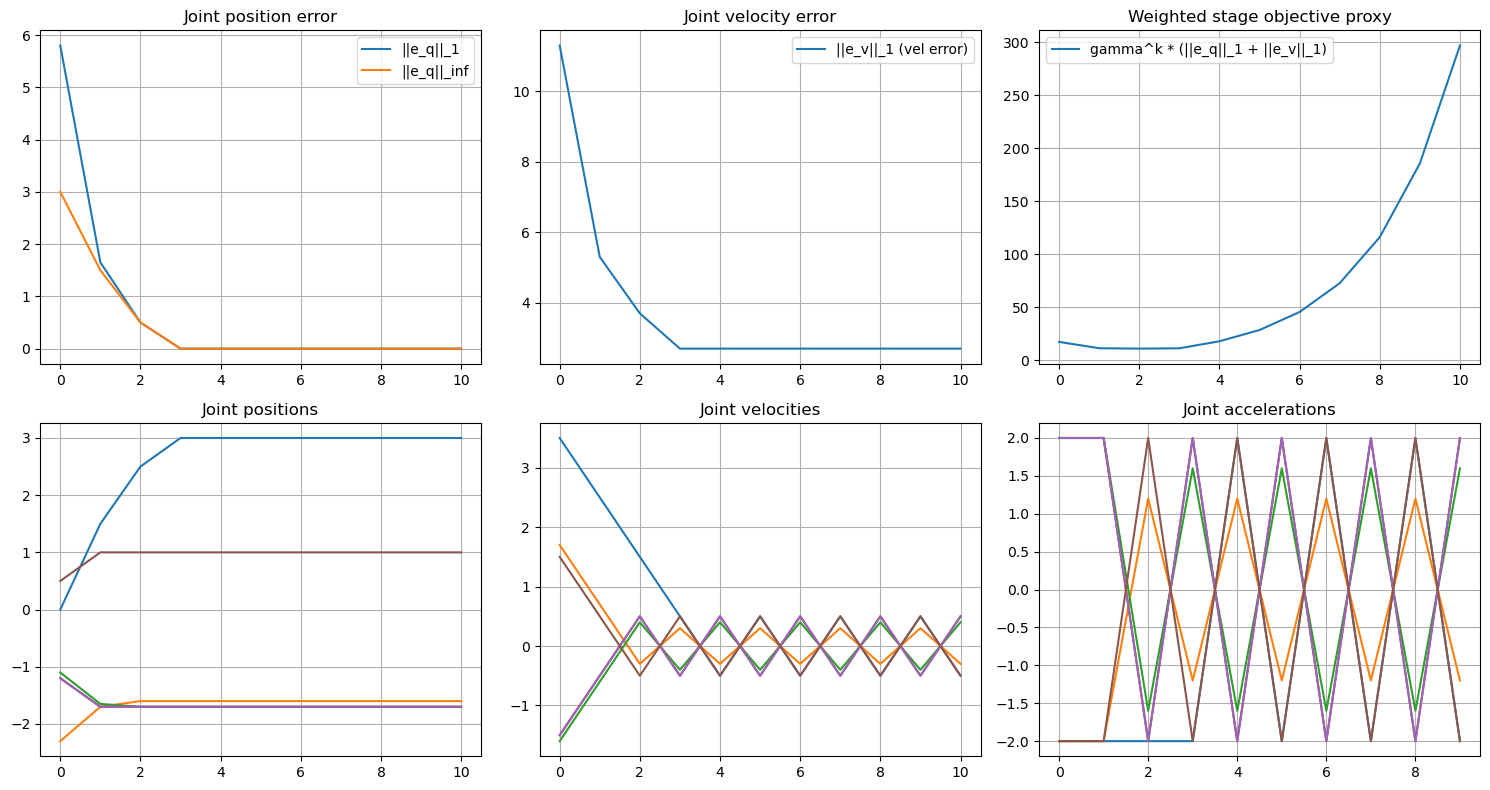

In [312]:
import numpy as np
import matplotlib.pyplot as plt

# collect trajectory
X = np.array([ocp_solver.get(k, "x") for k in range(N+1)])   # shape: (N+1, 12)
U = np.array([ocp_solver.get(k, "u") for k in range(N)])     # shape: (N, 18)

q = X[:, :6]
v = X[:, 6:12]
a = U[:, :6]
s_q = U[:, 6:12]
s_v = U[:, 12:18]

q_goal = xf.copy()
gamma = 1.6
w = np.array([gamma**k for k in range(N+1)])

e_q = q - q_goal[None, :]
e_v = v  # desired velocity = 0
e_q_l1 = np.sum(np.abs(e_q), axis=1)
e_q_linf = np.max(np.abs(e_q), axis=1)
e_v_l1 = np.sum(np.abs(e_v), axis=1)
weighted = w * (e_q_l1 + e_v_l1)

# "arrives early" index
tol_q = 2e-2
tol_v = 5e-2
arrive_idx = None
for k in range(N+1):
    if np.max(np.abs(q[k]-q_goal)) < tol_q and np.max(np.abs(v[k])) < tol_v:
        arrive_idx = k
        break

print("First arrival step:", arrive_idx)
print("Final ||q-q_goal||_inf:", e_q_linf[-1])
print("Final ||v||_inf:", np.max(np.abs(v[-1])))
print("Max |a|:", np.max(np.abs(a)))

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

ax[0,0].plot(e_q_l1, label='||e_q||_1')
ax[0,0].plot(e_q_linf, label='||e_q||_inf')
if arrive_idx is not None:
    ax[0,0].axvline(arrive_idx, color='r', ls='--', label='arrival')
ax[0,0].set_title("Joint position error")
ax[0,0].legend(); ax[0,0].grid(True)

ax[0,1].plot(e_v_l1, label='||e_v||_1 (vel error)')
ax[0,1].set_title("Joint velocity error")
ax[0,1].legend(); ax[0,1].grid(True)

ax[0,2].plot(weighted, label='gamma^k * (||e_q||_1 + ||e_v||_1)')
ax[0,2].set_title("Weighted stage objective proxy")
ax[0,2].legend(); ax[0,2].grid(True)

for j in range(6):
    ax[1,0].plot(q[:, j], label=f'q{j+1}')
ax[1,0].set_title("Joint positions")
ax[1,0].grid(True)

for j in range(6):
    ax[1,1].plot(v[:, j], label=f'v{j+1}')
ax[1,1].set_title("Joint velocities")
ax[1,1].grid(True)

for j in range(6):
    ax[1,2].plot(a[:, j], label=f'a{j+1}')
ax[1,2].set_title("Joint accelerations")
ax[1,2].grid(True)

plt.tight_layout()
plt.show()